# Utils

## Visualization Utils

In [1]:
from IPython.display import HTML, display
import html


def visualize_tokens(text, tokenizer):
    ids = tokenizer.encode(text)

    if hasattr(tokenizer, 'id_to_char'):
        tokens = [tokenizer.id_to_char[i] for i in ids]
    elif hasattr(tokenizer, 'id_to_trigram'):
        tokens = [tokenizer.id_to_trigram[i] for i in ids]
    elif hasattr(tokenizer, 'id_to_token'):
        tokens = []
        for i in ids:
            t = tokenizer.id_to_token[i]
            if hasattr(tokenizer, 'flatten_bytes') and t not in getattr(tokenizer, 'special_tokens', []):
                tokens.append(bytes(tokenizer.flatten_bytes(t)).decode('utf-8', errors='replace'))
            else:
                tokens.append(str(t))
    elif hasattr(tokenizer, 'tokenizer') and hasattr(tokenizer.tokenizer, 'convert_ids_to_tokens'):
        tokens = tokenizer.tokenizer.convert_ids_to_tokens(ids)
    elif hasattr(tokenizer, 'convert_ids_to_tokens'):
        tokens = tokenizer.convert_ids_to_tokens(ids)
    else:
        tokens = [str(i) for i in ids]

    colors = [
        "#ffd6d6", "#d6eaff", "#d6ffd9", "#fff5d6",
        "#ead6ff", "#d6fff6", "#ffe6cc", "#f0f0f0",
        "#ffcccc", "#cce5ff", "#ccffcc", "#fff0cc",
        "#e5ccff", "#ccfff2", "#ffddcc", "#e6e6e6",
        "#f7c6c7", "#c6def1", "#c9e4de", "#faedcb",
        "#dbcdf0", "#f2c6de", "#c6f1e7", "#f9dcc4",
        "#d0f4de", "#a9def9", "#e4c1f9", "#fcf6bd",
        "#ffdac1", "#b5ead7", "#c7ceea", "#ffb7b2",
    ]

    spans = []

    for token, token_id in zip(tokens, ids):
        color = colors[token_id % len(colors)]

        visible_token = token
        visible_token = visible_token.replace(" ", "␠")
        visible_token = visible_token.replace("\n", "↵")
        visible_token = visible_token.replace("\t", "⇥")

        spans.append(
            f"""
            <span style="
                background-color:{color};
                color:#000000;
                border:1px solid #777;
                border-radius:6px;
                padding:4px 6px;
                margin:3px;
                display:inline-block;
                font-family:monospace;
                font-size:15px;
                font-weight:600;
            " title="token: {html.escape(token)} | id: {token_id}">
                {html.escape(visible_token)}
                <sub style="color:#333333;">{token_id}</sub>
            </span>
            """
        )

    display(HTML(
        f"""
        <div style="
            line-height:2.4;
            max-width:900px;
            border:1px solid #888;
            background-color:#ffffff;
            color:#000000;
            padding:12px;
            border-radius:8px;
        ">
            {''.join(spans)}
        </div>
        """
    ))

# Loading WikiText Dataset

In [2]:
from datasets import load_dataset

wikitext = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

print(wikitext)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [3]:
# Computing and showing number of words

train_texts = [
    x["text"] for x in wikitext["train"]
    if x["text"].strip() # get rid of empty lines
]

valid_texts = [
    x["text"] for x in wikitext["validation"]
    if x["text"].strip()
]

test_texts = [
    x["text"] for x in wikitext["test"]
    if x["text"].strip()
]

print("Train:", len(train_texts))
print("Validation:", len(valid_texts))
print("Test:", len(test_texts))

Train: 23767
Validation: 2461
Test: 2891


In [4]:
for i, text in enumerate(train_texts[:5]):
    print(f"\nExample {i + 1}")
    print()
    print(text[:500])


Example 1

 = Valkyria Chronicles III = 


Example 2

 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and f

Example 3

 The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Character designer Raita Honjou and composer Hitoshi Sakimoto both returned from previous entries , along with Valkyria Chronicles II director Takeshi Ozawa . A

# Character Tokenizer

In [5]:
from collections import Counter


class CharacterTokenizer:
    def __init__(self):
        self.special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.bos_token = "<BOS>"
        self.eos_token = "<EOS>"

        self.char_to_id = {}
        self.id_to_char = {}

    def train(self, texts):
        counter = Counter()

        for text in texts:
            counter.update(text)

        vocab = self.special_tokens.copy()

        for char in counter.keys():
            vocab.append(char)

        self.char_to_id = {char: i for i, char in enumerate(vocab)}
        self.id_to_char = {i: char for char, i in self.char_to_id.items()}

        self.pad_id = self.char_to_id["<PAD>"]
        self.unk_id = self.char_to_id["<UNK>"]
        self.bos_id = self.char_to_id["<BOS>"]
        self.eos_id = self.char_to_id["<EOS>"]

    def encode(self, text, add_bos=False, add_eos=False):
        ids = []

        if add_bos:
            ids.append(self.bos_id)

        for char in text:
            ids.append(self.char_to_id.get(char, self.unk_id))

        if add_eos:
            ids.append(self.eos_id)

        return ids

    def decode(self, ids):
        chars = []

        for idx in ids:
            char = self.id_to_char[idx]

            if char not in self.special_tokens:
                chars.append(char)

        return "".join(chars)

    def vocab_size(self):
        return len(self.char_to_id)

## Train Character Tokenizer

In [6]:
character_tokenizer = CharacterTokenizer()
character_tokenizer.train(train_texts)

## Use & Stress Test Character Tokenizer

In [7]:
text = "Hello world!"

ids = character_tokenizer.encode(text, add_bos=True, add_eos=True)

print("Text:", text)
print("IDs:", ids)
print("Decoded:", character_tokenizer.decode(ids))
print("Vocab size:", character_tokenizer.vocab_size())
visualize_tokens(text, character_tokenizer)

Text: Hello world!
IDs: [2, 68, 18, 8, 8, 15, 4, 62, 15, 11, 8, 28, 142, 3]
Decoded: Hello world!
Vocab size: 1017


In [8]:
stress_texts = [
    "Hello world!",
    "HELLO WORLD!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in stress_texts:
    print("=" * 60)
    ids = character_tokenizer.encode(text, add_bos=True, add_eos=True)

    print("Text:", text)
    print("IDs:", ids)
    print("Decoded:", character_tokenizer.decode(ids))
    visualize_tokens(text, character_tokenizer)
    print()
    print()
    print()

Text: Hello world!
IDs: [2, 68, 18, 8, 8, 15, 4, 62, 15, 11, 8, 28, 142, 3]
Decoded: Hello world!





Text: HELLO WORLD!
IDs: [2, 68, 61, 80, 80, 69, 4, 66, 69, 57, 80, 74, 142, 3]
Decoded: HELLO WORLD!





Text: café
IDs: [2, 17, 7, 45, 136, 3]
Decoded: café





Text: naïve
IDs: [2, 16, 7, 412, 53, 18, 3]
Decoded: naïve





Text: 😊
IDs: [2, 1, 3]
Decoded: 





Text: katılamayanlardan
IDs: [2, 9, 7, 43, 605, 8, 7, 48, 7, 10, 7, 16, 8, 7, 11, 28, 7, 16, 3]
Decoded: katılamayanlardan





Text: 姚明进入总决赛
IDs: [2, 328, 326, 1, 1, 1, 1, 1, 3]
Decoded: 姚明


# Character Trigram Tokenizer
e.g. "hello" → ["<he", "hel", "ell", "llo", "lo>"]

In [9]:
from collections import Counter


class CharacterTrigramTokenizer:
    def __init__(self):
        self.special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.bos_token = "<BOS>"
        self.eos_token = "<EOS>"

        self.trigram_to_id = {}
        self.id_to_trigram = {}

    def make_trigrams(self, text):
        # Add boundary markers
        text = "<" + text + ">"

        trigrams = []

        for i in range(len(text) - 2):
            trigram = text[i:i+3]
            trigrams.append(trigram)

        return trigrams

    def train(self, texts):
        counter = Counter()

        for text in texts:
            trigrams = self.make_trigrams(text)
            counter.update(trigrams)

        vocab = self.special_tokens.copy()

        for trigram in counter.keys():
            vocab.append(trigram)

        self.trigram_to_id = {trigram: i for i, trigram in enumerate(vocab)}
        self.id_to_trigram = {i: trigram for trigram, i in self.trigram_to_id.items()}

        self.pad_id = self.trigram_to_id["<PAD>"]
        self.unk_id = self.trigram_to_id["<UNK>"]
        self.bos_id = self.trigram_to_id["<BOS>"]
        self.eos_id = self.trigram_to_id["<EOS>"]

    def encode(self, text, add_bos=False, add_eos=False):
        trigrams = self.make_trigrams(text)

        ids = []

        if add_bos:
            ids.append(self.bos_id)

        for trigram in trigrams:
            ids.append(self.trigram_to_id.get(trigram, self.unk_id))

        if add_eos:
            ids.append(self.eos_id)

        return ids

    def decode(self, ids):
        trigrams = []

        for idx in ids:
            trigram = self.id_to_trigram[idx]

            if trigram not in self.special_tokens:
                trigrams.append(trigram)

        if not trigrams:
            return ""

        # Reconstruct from overlapping trigrams
        # Example:
        # ["<he", "hel", "ell", "llo", "lo>"]
        # first trigram gives "<he"
        # each next trigram adds its final character
        text = trigrams[0]

        for trigram in trigrams[1:]:
            text += trigram[-1]

        # Remove boundary markers
        if text.startswith("<"):
            text = text[1:]

        if text.endswith(">"):
            text = text[:-1]

        return text

    def vocab_size(self):
        return len(self.trigram_to_id)

In [10]:
trigram_tokenizer = CharacterTrigramTokenizer()
trigram_tokenizer.train(train_texts)

print("Trigram vocab size:", trigram_tokenizer.vocab_size())

Trigram vocab size: 32613


In [11]:
stress_texts = [
    "Hello world!",
    "HELLO WORLD!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in stress_texts:
    print("=" * 60)
    ids = trigram_tokenizer.encode(text, add_bos=True, add_eos=True)

    print("Text:", text)
    print("IDs:", ids)
    print("Decoded:", trigram_tokenizer.decode(ids))
    visualize_tokens(text, trigram_tokenizer)
    print()
    print()
    print()

Text: Hello world!
IDs: [2, 1, 7846, 1750, 365, 6348, 1700, 532, 533, 2274, 2275, 1, 1, 3]
Decoded: Hello world





Text: HELLO WORLD!
IDs: [2, 1, 28753, 28754, 1, 1, 9946, 26094, 1, 1, 1, 1, 1, 3]
Decoded: HELLWO





Text: café
IDs: [2, 1, 11082, 17716, 1, 3]
Decoded: café





Text: naïve
IDs: [2, 1, 18792, 18793, 18794, 1, 3]
Decoded: naïve





Text: 😊
IDs: [2, 1, 3]
Decoded: 





Text: katılamayanlardan
IDs: [2, 1, 5875, 1, 1, 1, 480, 481, 3940, 2220, 2774, 5781, 8863, 524, 559, 7149, 1637, 1, 3]
Decoded: katmayanlardan





Text: 姚明进入总决赛
IDs: [2, 1, 1, 1, 1, 1, 1, 1, 3]
Decoded: 


# Character BPE

In [12]:
from collections import Counter, defaultdict


class CharBPETokenizer:
    def __init__(self, vocab_size=1000):
        self.vocab_size_target = vocab_size

        self.special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.bos_token = "<BOS>"
        self.eos_token = "<EOS>"

        self.merges = []
        self.token_to_id = {}
        self.id_to_token = {}

    def word_to_symbols(self, word):
        return tuple(list(word) + ["</w>"])

    def get_word_vocab(self, texts):
        word_freqs = Counter()

        for text in texts:
            words = text.split()
            word_freqs.update(words)

        word_vocab = {}

        for word, freq in word_freqs.items():
            word_vocab[self.word_to_symbols(word)] = freq

        return word_vocab

    def get_pair_counts(self, word_vocab):
        pair_counts = defaultdict(int)

        for symbols, freq in word_vocab.items():
            for i in range(len(symbols) - 1):
                pair = (symbols[i], symbols[i + 1])
                pair_counts[pair] += freq

        return pair_counts

    def merge_pair(self, pair, word_vocab):
        new_word_vocab = {}

        for symbols, freq in word_vocab.items():
            new_symbols = []
            i = 0

            while i < len(symbols):
                if (
                    i < len(symbols) - 1
                    and symbols[i] == pair[0]
                    and symbols[i + 1] == pair[1]
                ):
                    new_symbols.append(pair[0] + pair[1])
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1

            new_word_vocab[tuple(new_symbols)] = freq

        return new_word_vocab

    def train(self, texts):
        word_vocab = self.get_word_vocab(texts)

        # initial vocabulary: characters + </w>
        tokens = set()
        for symbols in word_vocab:
            tokens.update(symbols)

        while len(tokens) + len(self.special_tokens) < self.vocab_size_target:
            pair_counts = self.get_pair_counts(word_vocab)

            if not pair_counts:
                break

            best_pair = max(pair_counts, key=pair_counts.get)

            if pair_counts[best_pair] < 2:
                break

            self.merges.append(best_pair)
            word_vocab = self.merge_pair(best_pair, word_vocab)

            tokens.add(best_pair[0] + best_pair[1])

        final_tokens = set()
        for symbols in word_vocab:
            final_tokens.update(symbols)

        vocab = self.special_tokens + sorted(final_tokens)

        self.token_to_id = {token: i for i, token in enumerate(vocab)}
        self.id_to_token = {i: token for token, i in self.token_to_id.items()}

        self.pad_id = self.token_to_id["<PAD>"]
        self.unk_id = self.token_to_id["<UNK>"]
        self.bos_id = self.token_to_id["<BOS>"]
        self.eos_id = self.token_to_id["<EOS>"]

    def apply_merges(self, symbols):
        symbols = list(symbols)

        for pair in self.merges:
            new_symbols = []
            i = 0

            while i < len(symbols):
                if (
                    i < len(symbols) - 1
                    and symbols[i] == pair[0]
                    and symbols[i + 1] == pair[1]
                ):
                    new_symbols.append(pair[0] + pair[1])
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1

            symbols = new_symbols

        return symbols

    def tokenize(self, text):
        tokens = []

        for word in text.split():
            symbols = self.word_to_symbols(word)
            word_tokens = self.apply_merges(symbols)
            tokens.extend(word_tokens)

        return tokens

    def encode(self, text, add_bos=False, add_eos=False):
        tokens = self.tokenize(text)

        ids = []

        if add_bos:
            ids.append(self.bos_id)

        for token in tokens:
            ids.append(self.token_to_id.get(token, self.unk_id))

        if add_eos:
            ids.append(self.eos_id)

        return ids

    def decode(self, ids):
        tokens = []

        for idx in ids:
            token = self.id_to_token[idx]

            if token not in self.special_tokens:
                tokens.append(token)

        text = "".join(tokens)
        text = text.replace("</w>", " ")

        return text.strip()

    def vocab_size(self):
        return len(self.token_to_id)

In [13]:
bpe_tokenizer_2k = CharBPETokenizer(vocab_size=2000)
bpe_tokenizer_2k.train(train_texts)

print("BPE vocab size:", bpe_tokenizer_2k.vocab_size())
print("Number of learned merges:", len(bpe_tokenizer_2k.merges))

BPE vocab size: 1986
Number of learned merges: 984


In [14]:
stress_texts = [
    "Hello world!",
    "HELLO WORLD!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in stress_texts:
    print("=" * 60)
    ids = bpe_tokenizer_2k.encode(text, add_bos=True, add_eos=True)

    print("Text:", text)
    print("IDs:", ids)
    print("Decoded:", bpe_tokenizer_2k.decode(ids))
    visualize_tokens(text, bpe_tokenizer_2k)
    print()
    print()
    print()

Text: Hello world!
IDs: [2, 111, 428, 705, 1050, 626, 369, 4, 67, 3]
Decoded: Hello world!





Text: HELLO WORLD!
IDs: [2, 111, 103, 130, 130, 141, 67, 167, 141, 149, 130, 102, 4, 67, 3]
Decoded: HELLO WORLD!





Text: café
IDs: [2, 329, 484, 1111, 67, 3]
Decoded: café





Text: naïve
IDs: [2, 685, 181, 1117, 1024, 3]
Decoded: naïve





Text: 😊
IDs: [2, 1, 67, 3]
Decoded: 





Text: katılamayanlardan
IDs: [2, 617, 269, 1150, 626, 228, 290, 233, 631, 369, 234, 3]
Decoded: katılamayanlardan





Text: 姚明进入总决赛
IDs: [2, 1739, 1800, 1, 1, 1, 1, 1, 67, 3]
Decoded: 姚明


# UTF-8 BPE

In [15]:
from collections import Counter, defaultdict


class ByteBPETokenizer:
    def __init__(self, vocab_size=1000):
        self.vocab_size_target = vocab_size

        self.special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.bos_token = "<BOS>"
        self.eos_token = "<EOS>"

        self.merges = []

        self.token_to_id = {}
        self.id_to_token = {}

    def text_to_bytes(self, text):
        return tuple(text.encode("utf-8"))

    def get_byte_vocab(self, texts):
        """
        Build initial corpus representation.

        Each text becomes a tuple of byte symbols plus an end marker.
        Example:
            "hi" -> (104, 105, "</w>")
        """
        byte_freqs = Counter()

        for text in texts:
            if text.strip():
                byte_seq = self.text_to_bytes(text)
                byte_freqs[byte_seq + ("</w>",)] += 1

        return byte_freqs

    def get_pair_counts(self, vocab):
        pair_counts = defaultdict(int)

        for symbols, freq in vocab.items():
            for i in range(len(symbols) - 1):
                pair = (symbols[i], symbols[i + 1])
                pair_counts[pair] += freq

        return pair_counts

    def merge_pair(self, pair, vocab):
        new_vocab = Counter()

        for symbols, freq in vocab.items():
            new_symbols = []
            i = 0

            while i < len(symbols):
                if (
                    i < len(symbols) - 1
                    and symbols[i] == pair[0]
                    and symbols[i + 1] == pair[1]
                ):
                    new_symbols.append(pair)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1

            new_vocab[tuple(new_symbols)] += freq

        return new_vocab

    def train(self, texts):
        vocab = self.get_byte_vocab(texts)

        # Initial symbols are bytes 0-255 plus </w>
        symbols = set()
        for seq in vocab:
            symbols.update(seq)

        while len(symbols) + len(self.special_tokens) < self.vocab_size_target:
            pair_counts = self.get_pair_counts(vocab)

            if not pair_counts:
                break

            best_pair = max(pair_counts, key=pair_counts.get)

            if pair_counts[best_pair] < 2:
                break

            self.merges.append(best_pair)
            vocab = self.merge_pair(best_pair, vocab)

            symbols.add(best_pair)

        final_symbols = set()
        for seq in vocab:
            final_symbols.update(seq)

        vocab_tokens = self.special_tokens + list(final_symbols)

        self.token_to_id = {token: i for i, token in enumerate(vocab_tokens)}
        self.id_to_token = {i: token for token, i in self.token_to_id.items()}

        self.pad_id = self.token_to_id["<PAD>"]
        self.unk_id = self.token_to_id["<UNK>"]
        self.bos_id = self.token_to_id["<BOS>"]
        self.eos_id = self.token_to_id["<EOS>"]

    def apply_merges(self, symbols):
        symbols = list(symbols)

        for pair in self.merges:
            new_symbols = []
            i = 0

            while i < len(symbols):
                if (
                    i < len(symbols) - 1
                    and symbols[i] == pair[0]
                    and symbols[i + 1] == pair[1]
                ):
                    new_symbols.append(pair)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1

            symbols = new_symbols

        return symbols

    def tokenize(self, text):
        byte_seq = self.text_to_bytes(text)
        symbols = byte_seq + ("</w>",)

        return self.apply_merges(symbols)

    def encode(self, text, add_bos=False, add_eos=False):
        tokens = self.tokenize(text)

        ids = []

        if add_bos:
            ids.append(self.bos_id)

        for token in tokens:
            ids.append(self.token_to_id.get(token, self.unk_id))

        if add_eos:
            ids.append(self.eos_id)

        return ids

    def flatten_bytes(self, token):
        """
        Convert a byte-BPE token back into raw byte values.

        A token may be:
            97
            (97, 98)
            ((97, 98), 99)
            "</w>"
        """
        if token == "</w>":
            return []

        if isinstance(token, int):
            return [token]

        if isinstance(token, tuple):
            result = []
            for part in token:
                result.extend(self.flatten_bytes(part))
            return result

        return []

    def decode(self, ids):
        byte_values = []

        for idx in ids:
            token = self.id_to_token[idx]

            if token in self.special_tokens:
                continue

            byte_values.extend(self.flatten_bytes(token))

        return bytes(byte_values).decode("utf-8", errors="replace") # if not decoded properly, replace with "�"

    def vocab_size(self):
        return len(self.token_to_id)

In [16]:
byte_bpe_tokenizer = ByteBPETokenizer(vocab_size=500)
byte_bpe_tokenizer.train(train_texts[:5000])

print("Byte BPE vocab size:", byte_bpe_tokenizer.vocab_size())
print("Number of learned merges:", len(byte_bpe_tokenizer.merges))

Byte BPE vocab size: 495
Number of learned merges: 313


In [17]:
texts = [
    "Hello world!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in texts:
    ids = byte_bpe_tokenizer.encode(text, add_bos=True, add_eos=True)
    decoded = byte_bpe_tokenizer.decode(ids)

    print("=" * 60)
    print("Text:", text)
    print("IDs:", ids)
    print("Decoded:", decoded)
    print("Tokens:", byte_bpe_tokenizer.tokenize(text))
    visualize_tokens(text, byte_bpe_tokenizer)
    print()
    print()
    print()

Text: Hello world!
IDs: [2, 48, 430, 83, 438, 5, 83, 75, 9, 1, 3]
Decoded: Hello world!
Tokens: [72, (101, 108), 108, (111, 32), (119, (111, 114)), 108, 100, 33, '</w>']





Text: café
IDs: [2, 74, 72, 77, 167, 141, 1, 3]
Decoded: café
Tokens: [99, 97, 102, 195, 169, '</w>']





Text: naïve
IDs: [2, 85, 72, 167, 150, 94, 76, 1, 3]
Decoded: naïve
Tokens: [110, 97, 195, 175, 118, 101, '</w>']





Text: 😊
IDs: [2, 1, 131, 124, 110, 1, 3]
Decoded: ���
Tokens: [240, 159, 152, 138, '</w>']





Text: katılamayanlardan
IDs: [2, 82, 412, 168, 155, 83, 237, 399, 451, 83, 221, 75, 451, 1, 3]
Decoded: katılamayanlardan
Tokens: [107, (97, 116), 196, 177, 108, (97, 109), (97, 121), (97, 110), 108, (97, 114), 100, (97, 110), '</w>']





Text: 姚明进入总决赛
IDs: [2, 193, 144, 295, 194, 124, 114, 199, 164, 127, 193, 105, 137, 194, 100, 329, 193, 106, 319, 199, 156, 127, 1, 3]
Decoded: 姚明进入总决赛
Tokens: [229, 167, 154, 230, 152, 142, 232, 191, 155, 229, 133, 165, 230, 128, 187, 229, 134, 179, 232, 181, 155, '</w>']


# WordPiece

1. Build a vocabulary of possible subwords.
2. Mark continuation subwords with ##.
3. Encode new words using greedy longest-match-first.

```text
playing ->

p
pl
pla
play
playi
playin
playing
##l
##la
##lay
##layi
##layin
##laying
##a
##ay
##ayi
...
```

In [18]:
from collections import Counter


class WordPieceTokenizer:
    def __init__(self, vocab_size=1000, max_subword_length=10):
        self.vocab_size_target = vocab_size
        self.max_subword_length = max_subword_length

        self.special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.bos_token = "<BOS>"
        self.eos_token = "<EOS>"

        self.token_to_id = {}
        self.id_to_token = {}

    def get_candidates(self, word):
        candidates = []

        for start in range(len(word)):
            max_end = min(len(word), start + self.max_subword_length)

            for end in range(start + 1, max_end + 1):
                piece = word[start:end]

                if start == 0:
                    candidates.append(piece)
                else:
                    candidates.append("##" + piece)

        return candidates

    def train(self, texts):
        candidate_counts = Counter()
        character_tokens = set()

        for text in texts:
            words = text.lower().split()

            for word in words:
                # Character fallback tokens
                for i, char in enumerate(word):
                    if i == 0:
                        character_tokens.add(char)
                    else:
                        character_tokens.add("##" + char)

                    # Also allow any char to appear as continuation
                    character_tokens.add("##" + char)

                # Candidate subwords
                candidates = self.get_candidates(word)
                candidate_counts.update(candidates)

        scored_candidates = []

        for piece, freq in candidate_counts.items():
            clean_piece = piece.replace("##", "")
            score = freq * len(clean_piece)
            scored_candidates.append((score, piece))

        scored_candidates.sort(reverse=True)

        vocab = self.special_tokens.copy()

        for token in sorted(character_tokens):
            if token not in vocab:
                vocab.append(token)

        for score, piece in scored_candidates:
            if len(vocab) >= self.vocab_size_target:
                break

            if piece not in vocab:
                vocab.append(piece)

        self.token_to_id = {token: i for i, token in enumerate(vocab)}
        self.id_to_token = {i: token for token, i in self.token_to_id.items()}

        self.pad_id = self.token_to_id["<PAD>"]
        self.unk_id = self.token_to_id["<UNK>"]
        self.bos_id = self.token_to_id["<BOS>"]
        self.eos_id = self.token_to_id["<EOS>"]

    def tokenize_word(self, word):
        word = word.lower()

        tokens = []
        start = 0

        while start < len(word):
            found = None

            max_end = min(len(word), start + self.max_subword_length)

            for end in range(max_end, start, -1):
                piece = word[start:end]

                if start > 0:
                    piece = "##" + piece

                if piece in self.token_to_id:
                    found = piece
                    break

            if found is None:
                return [self.unk_token]

            tokens.append(found)

            # Remove ## before measuring consumed characters
            consumed = len(found.replace("##", ""))
            start += consumed

        return tokens

    def tokenize(self, text):
        tokens = []

        for word in text.split():
            word_tokens = self.tokenize_word(word)
            tokens.extend(word_tokens)

        return tokens

    def encode(self, text, add_bos=False, add_eos=False):
        tokens = self.tokenize(text)

        ids = []

        if add_bos:
            ids.append(self.bos_id)

        for token in tokens:
            ids.append(self.token_to_id.get(token, self.unk_id))

        if add_eos:
            ids.append(self.eos_id)

        return ids

    def decode(self, ids):
        tokens = []

        for idx in ids:
            token = self.id_to_token[idx]

            if token not in self.special_tokens:
                tokens.append(token)

        text = ""

        for token in tokens:
            if token.startswith("##"):
                text += token[2:]
            else:
                if text:
                    text += " "
                text += token

        return text

    def vocab_size(self):
        return len(self.token_to_id)

In [19]:
wordpiece_tokenizer = WordPieceTokenizer(
    vocab_size=5000,
    max_subword_length=10
)

wordpiece_tokenizer.train(train_texts)

print("WordPiece vocab size:", wordpiece_tokenizer.vocab_size())

WordPiece vocab size: 5000


In [20]:
texts = [
    "Hello world!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in texts:
    ids = wordpiece_tokenizer.encode(text, add_bos=True, add_eos=True)
    decoded = wordpiece_tokenizer.decode(ids)

    print("=" * 60)
    print("Text:", text)
    print("IDs:", ids)
    print("Decoded:", decoded)
    print("Tokens:", wordpiece_tokenizer.tokenize(text))
    visualize_tokens(text, wordpiece_tokenizer)
    print()
    print()
    print()

Text: Hello world!
IDs: [2, 3598, 1566, 2543, 7, 3]
Decoded: hello world!
Tokens: ['hel', '##lo', 'world', '##!']





Text: café
IDs: [2, 1574, 50, 102, 3]
Decoded: café
Tokens: ['ca', '##f', '##é']





Text: naïve
IDs: [2, 2052, 108, 1462, 3]
Decoded: naïve
Tokens: ['na', '##ï', '##ve']





Text: 😊
IDs: [2, 1, 3]
Decoded: 
Tokens: ['<UNK>']





Text: katılamayanlardan
IDs: [2, 990, 1441, 135, 1488, 1563, 4553, 2759, 1702, 1444, 3]
Decoded: katılamayanlardan
Tokens: ['k', '##at', '##ı', '##la', '##ma', '##ya', '##nl', '##ard', '##an']





Text: 姚明进入总决赛
IDs: [2, 1, 3]
Decoded: 
Tokens: ['<UNK>']


# SentencePiece
1. Replace spaces with ▁
2. Build candidate pieces from raw text
3. Assign each piece a probability/cost
4. Use Viterbi dynamic programming to find the best segmentation
5. Decode by joining pieces and turning ▁ back into spaces

In [21]:
from collections import Counter
import math


class SentencePieceTokenizer:
    def __init__(self, vocab_size=5000, max_piece_length=12):
        self.vocab_size_target = vocab_size
        self.max_piece_length = max_piece_length

        self.special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.bos_token = "<BOS>"
        self.eos_token = "<EOS>"

        self.space_marker = "▁"

        self.token_to_id = {}
        self.id_to_token = {}
        self.piece_costs = {}

    def normalize(self, text):
        """
        SentencePiece-style normalization:
        spaces become ▁, and we add ▁ to the beginning.
        """
        text = text.strip()
        text = text.replace(" ", self.space_marker)
        return self.space_marker + text

    def get_candidates(self, text):
        """
        Generate all substring candidates up to max_piece_length.
        """
        text = self.normalize(text)
        candidates = []

        for start in range(len(text)):
            max_end = min(len(text), start + self.max_piece_length)

            for end in range(start + 1, max_end + 1):
                piece = text[start:end]
                candidates.append(piece)

        return candidates

    def train(self, texts):
        """
        Train a simplified unigram vocabulary.

        This does not implement full EM training like real SentencePiece.
        Instead:
        - collect substring candidates
        - score them by frequency × length
        - keep the best pieces
        - assign costs using -log frequency probability
        """
        candidate_counts = Counter()
        character_pieces = set()

        for text in texts:
            normalized = self.normalize(text)

            # Character fallback: guarantees that seen characters can be segmented.
            for char in normalized:
                character_pieces.add(char)

            # Candidate pieces.
            candidates = self.get_candidates(text)
            candidate_counts.update(candidates)

        scored_candidates = []

        for piece, freq in candidate_counts.items():
            score = freq * len(piece)
            scored_candidates.append((score, piece, freq))

        scored_candidates.sort(reverse=True)

        vocab = self.special_tokens.copy()

        # Always include single-character fallback pieces.
        for char in sorted(character_pieces):
            if char not in vocab:
                vocab.append(char)

        # Add high-scoring multi-character pieces.
        for score, piece, freq in scored_candidates:
            if len(vocab) >= self.vocab_size_target:
                break

            if piece not in vocab:
                vocab.append(piece)

        self.token_to_id = {token: i for i, token in enumerate(vocab)}
        self.id_to_token = {i: token for token, i in self.token_to_id.items()}

        self.pad_id = self.token_to_id[self.pad_token]
        self.unk_id = self.token_to_id[self.unk_token]
        self.bos_id = self.token_to_id[self.bos_token]
        self.eos_id = self.token_to_id[self.eos_token]

        # Convert counts into costs.
        # Lower cost = more likely piece.
        total_count = sum(candidate_counts.values())

        self.piece_costs = {}

        for piece in vocab:
            if piece in self.special_tokens:
                continue

            freq = candidate_counts.get(piece, 1)
            prob = freq / total_count
            self.piece_costs[piece] = -math.log(prob)

    def tokenize(self, text):
        """
        Tokenize using Viterbi dynamic programming.

        Finds the minimum-cost segmentation of the normalized text.
        """
        text = self.normalize(text)
        n = len(text)

        # dp[i] = best cost for tokenizing text[:i]
        dp = [float("inf")] * (n + 1)

        # backpointer[i] = (previous_position, chosen_piece)
        backpointer = [None] * (n + 1)

        dp[0] = 0.0

        for i in range(n):
            if dp[i] == float("inf"):
                continue

            max_j = min(n, i + self.max_piece_length)

            for j in range(i + 1, max_j + 1):
                piece = text[i:j]

                if piece in self.token_to_id:
                    piece_cost = self.piece_costs.get(piece, 100.0)
                    new_cost = dp[i] + piece_cost

                    if new_cost < dp[j]:
                        dp[j] = new_cost
                        backpointer[j] = (i, piece)

        # If no full segmentation is possible, return <UNK>.
        if dp[n] == float("inf"):
            return [self.unk_token]

        # Recover best segmentation.
        pieces = []
        position = n

        while position > 0:
            previous_position, piece = backpointer[position]
            pieces.append(piece)
            position = previous_position

        pieces.reverse()
        return pieces

    def encode(self, text, add_bos=False, add_eos=False):
        pieces = self.tokenize(text)

        ids = []

        if add_bos:
            ids.append(self.bos_id)

        for piece in pieces:
            ids.append(self.token_to_id.get(piece, self.unk_id))

        if add_eos:
            ids.append(self.eos_id)

        return ids

    def decode(self, ids):
        pieces = []

        for idx in ids:
            piece = self.id_to_token[int(idx)]

            if piece not in self.special_tokens:
                pieces.append(piece)

        text = "".join(pieces)
        text = text.replace(self.space_marker, " ")

        return text.strip()

    def vocab_size(self):
        return len(self.token_to_id)

In [22]:
sp_tokenizer = SentencePieceTokenizer(
    vocab_size=5000,
    max_piece_length=20
)

sp_tokenizer.train(train_texts[:5000])

print("Vocab size:", sp_tokenizer.vocab_size())

Vocab size: 5000


In [23]:
texts = [
    "Hello world!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in texts:
    ids = sp_tokenizer.encode(text, add_bos=True, add_eos=True)
    decoded = sp_tokenizer.decode(ids)

    print("=" * 60)
    print("Text:", text)
    print("Pieces:", sp_tokenizer.tokenize(text))
    print("IDs:", ids)
    print("Decoded:", decoded)
    visualize_tokens(text, sp_tokenizer)
    print()

Text: Hello world!
Pieces: ['▁He', 'llo', '▁w', 'orld', '!']
IDs: [2, 2059, 2399, 457, 4957, 4, 3]
Decoded: Hello world!



Text: café
Pieces: ['▁ca', 'f', 'é']
IDs: [2, 890, 71, 118, 3]
Decoded: café



Text: naïve
Pieces: ['<UNK>']
IDs: [2, 1, 3]
Decoded: 



Text: 😊
Pieces: ['<UNK>']
IDs: [2, 1, 3]
Decoded: 



Text: katılamayanlardan
Pieces: ['<UNK>']
IDs: [2, 1, 3]
Decoded: 



Text: 姚明进入总决赛
Pieces: ['<UNK>']
IDs: [2, 1, 3]
Decoded: 


# Model Training

## Utils

In [24]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [39]:
ppl_results = {}
history_results = {}

input:  token_0 token_1 token_2 ... token_n-1 \
target: token_1 token_2 token_3 ... token_n

In [38]:
def build_lm_blocks(texts, tokenizer, block_size=256):
    all_ids = []

    for text in texts:
        ids = tokenizer.encode(text, add_bos=True, add_eos=True)
        all_ids.extend(ids)

    blocks = []

    for i in range(0, len(all_ids) - block_size, block_size):
        chunk = all_ids[i : i + block_size + 1]

        if len(chunk) == block_size + 1:
            input_ids = chunk[:-1]
            target_ids = chunk[1:]

            blocks.append((input_ids, target_ids))

    return blocks

In [27]:
class LMDataset(Dataset):
    def __init__(self, blocks):
        self.blocks = blocks

    def __len__(self):
        return len(self.blocks)

    def __getitem__(self, idx):
        input_ids, target_ids = self.blocks[idx]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "target_ids": torch.tensor(target_ids, dtype=torch.long),
        }

In [28]:
class LSTMLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        emb_dim=128,
        hidden_dim=256,
        num_layers=1,
        dropout=0.1,
        pad_id=0,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=pad_id
        )

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        h, _ = self.lstm(x)
        logits = self.output(h)
        return logits

In [41]:
import matplotlib.pyplot as plt
import math


ppl_results = {}
history_results = {}


def count_tokens_and_chars(texts, tokenizer):
    total_tokens = 0
    total_chars = 0

    for text in texts:
        ids = tokenizer.encode(text, add_bos=False, add_eos=False)
        total_tokens += len(ids)
        total_chars += len(text)

    return total_tokens, total_chars


def train_lstm_lm_with_tokenizer(
    tokenizer,
    tokenizer_name,
    ppl_results,
    history_results=None,
    block_size=256,
    batch_size=64,
    epochs=5,
    emb_dim=128,
    hidden_dim=256,
    num_layers=1,
    dropout=0.1,
    lr=1e-3,
):
    train_blocks = build_lm_blocks(train_texts, tokenizer, block_size=block_size)
    valid_blocks = build_lm_blocks(valid_texts, tokenizer, block_size=block_size)

    train_dataset = LMDataset(train_blocks)
    valid_dataset = LMDataset(valid_blocks)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

    model = LSTMLanguageModel(
        vocab_size=tokenizer.vocab_size(),
        emb_dim=emb_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        pad_id=tokenizer.pad_id,
    ).to(device)

    loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_id)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr
    )

    history = {
        "train_token_loss": [],
        "val_token_loss": [],
        "train_token_ppl": [],
        "val_token_ppl": [],
        "train_char_loss": [],
        "val_char_loss": [],
        "train_char_ppl": [],
        "val_char_ppl": [],
    }

    train_tokens, train_chars = count_tokens_and_chars(train_texts, tokenizer)
    valid_tokens, valid_chars = count_tokens_and_chars(valid_texts, tokenizer)

    train_tokens_per_char = train_tokens / train_chars
    valid_tokens_per_char = valid_tokens / valid_chars

    def run_epoch(train=True):
        model.train() if train else model.eval()
        loader = train_loader if train else valid_loader

        total_loss = 0.0
        total_tokens = 0

        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)

            if train:
                optimizer.zero_grad()

            logits = model(input_ids)
            vocab_size = logits.size(-1)

            loss = loss_fn(
                logits.reshape(-1, vocab_size),
                target_ids.reshape(-1)
            )

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            num_tokens = target_ids.numel()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

        token_loss = total_loss / total_tokens
        token_ppl = math.exp(token_loss)

        return token_loss, token_ppl

    for epoch in range(1, epochs + 1):
        train_token_loss, train_token_ppl = run_epoch(train=True)

        with torch.no_grad():
            val_token_loss, val_token_ppl = run_epoch(train=False)

        train_char_loss = train_token_loss * train_tokens_per_char
        val_char_loss = val_token_loss * valid_tokens_per_char

        train_char_ppl = math.exp(train_char_loss)
        val_char_ppl = math.exp(val_char_loss)

        history["train_token_loss"].append(train_token_loss)
        history["val_token_loss"].append(val_token_loss)
        history["train_token_ppl"].append(train_token_ppl)
        history["val_token_ppl"].append(val_token_ppl)

        history["train_char_loss"].append(train_char_loss)
        history["val_char_loss"].append(val_char_loss)
        history["train_char_ppl"].append(train_char_ppl)
        history["val_char_ppl"].append(val_char_ppl)

        print(
            f"Epoch {epoch:02d} | "
            f"Train token loss: {train_token_loss:.4f} | "
            f"Train token PPL: {train_token_ppl:.2f} | "
            f"Val token loss: {val_token_loss:.4f} | "
            f"Val token PPL: {val_token_ppl:.2f} | "
            f"Val char PPL: {val_char_ppl:.2f}"
        )

    ppl_results[tokenizer_name] = {
        "final_train_token_loss": history["train_token_loss"][-1],
        "final_val_token_loss": history["val_token_loss"][-1],
        "final_train_token_ppl": history["train_token_ppl"][-1],
        "final_val_token_ppl": history["val_token_ppl"][-1],

        "final_train_char_loss": history["train_char_loss"][-1],
        "final_val_char_loss": history["val_char_loss"][-1],
        "final_train_char_ppl": history["train_char_ppl"][-1],
        "final_val_char_ppl": history["val_char_ppl"][-1],

        "train_tokens_per_char": train_tokens_per_char,
        "valid_tokens_per_char": valid_tokens_per_char,

        "vocab_size": tokenizer.vocab_size(),
        "block_size": block_size,
    }

    if history_results is not None:
        history_results[tokenizer_name] = history

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_char_loss"], label="Train char-normalized loss")
    plt.plot(history["val_char_loss"], label="Validation char-normalized loss")
    plt.xlabel("Epoch")
    plt.ylabel("Character-normalized loss")
    plt.title(f"LSTM LM Character-Normalized Loss — {tokenizer_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, history

## Tokenizer and training

Epoch 01 | Train token loss: 2.3138 | Train token PPL: 10.11 | Val token loss: 1.9724 | Val token PPL: 7.19 | Val char PPL: 7.19
Epoch 02 | Train token loss: 1.8812 | Train token PPL: 6.56 | Val token loss: 1.7973 | Val token PPL: 6.03 | Val char PPL: 6.03
Epoch 03 | Train token loss: 1.7493 | Train token PPL: 5.75 | Val token loss: 1.6970 | Val token PPL: 5.46 | Val char PPL: 5.46
Epoch 04 | Train token loss: 1.6642 | Train token PPL: 5.28 | Val token loss: 1.6286 | Val token PPL: 5.10 | Val char PPL: 5.10
Epoch 05 | Train token loss: 1.6017 | Train token PPL: 4.96 | Val token loss: 1.5775 | Val token PPL: 4.84 | Val char PPL: 4.84
Epoch 06 | Train token loss: 1.5546 | Train token PPL: 4.73 | Val token loss: 1.5419 | Val token PPL: 4.67 | Val char PPL: 4.67
Epoch 07 | Train token loss: 1.5184 | Train token PPL: 4.57 | Val token loss: 1.5143 | Val token PPL: 4.55 | Val char PPL: 4.55
Epoch 08 | Train token loss: 1.4903 | Train token PPL: 4.44 | Val token loss: 1.4922 | Val token PPL: 4

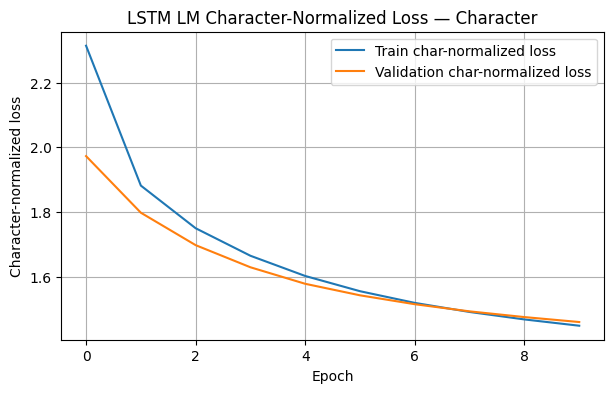

In [42]:
char_model, char_history = train_lstm_lm_with_tokenizer(
    tokenizer=character_tokenizer,
    tokenizer_name="Character",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

Epoch 01 | Train token loss: 3.8827 | Train token PPL: 48.56 | Val token loss: 2.0491 | Val token PPL: 7.76 | Val char PPL: 7.76
Epoch 02 | Train token loss: 1.7841 | Train token PPL: 5.95 | Val token loss: 1.7097 | Val token PPL: 5.53 | Val char PPL: 5.53
Epoch 03 | Train token loss: 1.5701 | Train token PPL: 4.81 | Val token loss: 1.5895 | Val token PPL: 4.90 | Val char PPL: 4.90
Epoch 04 | Train token loss: 1.4683 | Train token PPL: 4.34 | Val token loss: 1.5211 | Val token PPL: 4.58 | Val char PPL: 4.58
Epoch 05 | Train token loss: 1.4052 | Train token PPL: 4.08 | Val token loss: 1.4811 | Val token PPL: 4.40 | Val char PPL: 4.40
Epoch 06 | Train token loss: 1.3611 | Train token PPL: 3.90 | Val token loss: 1.4527 | Val token PPL: 4.27 | Val char PPL: 4.27
Epoch 07 | Train token loss: 1.3280 | Train token PPL: 3.77 | Val token loss: 1.4337 | Val token PPL: 4.19 | Val char PPL: 4.19
Epoch 08 | Train token loss: 1.3020 | Train token PPL: 3.68 | Val token loss: 1.4190 | Val token PPL: 4

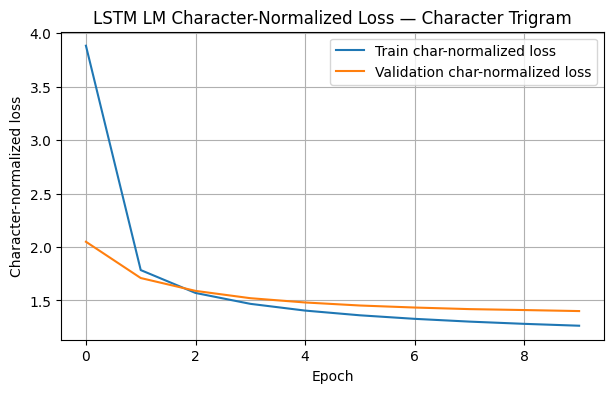

In [43]:
trigram_model, trigram_history = train_lstm_lm_with_tokenizer(
    tokenizer=trigram_tokenizer,
    tokenizer_name="Character Trigram",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

Epoch 01 | Train token loss: 5.6242 | Train token PPL: 277.06 | Val token loss: 4.8711 | Val token PPL: 130.46 | Val char PPL: 6.11
Epoch 02 | Train token loss: 4.5785 | Train token PPL: 97.37 | Val token loss: 4.3631 | Val token PPL: 78.50 | Val char PPL: 5.06
Epoch 03 | Train token loss: 4.2411 | Train token PPL: 69.48 | Val token loss: 4.1478 | Val token PPL: 63.30 | Val char PPL: 4.67
Epoch 04 | Train token loss: 4.0618 | Train token PPL: 58.08 | Val token loss: 4.0163 | Val token PPL: 55.49 | Val char PPL: 4.45
Epoch 05 | Train token loss: 3.9405 | Train token PPL: 51.44 | Val token loss: 3.9245 | Val token PPL: 50.63 | Val char PPL: 4.30
Epoch 06 | Train token loss: 3.8510 | Train token PPL: 47.04 | Val token loss: 3.8570 | Val token PPL: 47.32 | Val char PPL: 4.19
Epoch 07 | Train token loss: 3.7815 | Train token PPL: 43.88 | Val token loss: 3.8046 | Val token PPL: 44.91 | Val char PPL: 4.11
Epoch 08 | Train token loss: 3.7244 | Train token PPL: 41.45 | Val token loss: 3.7630 | 

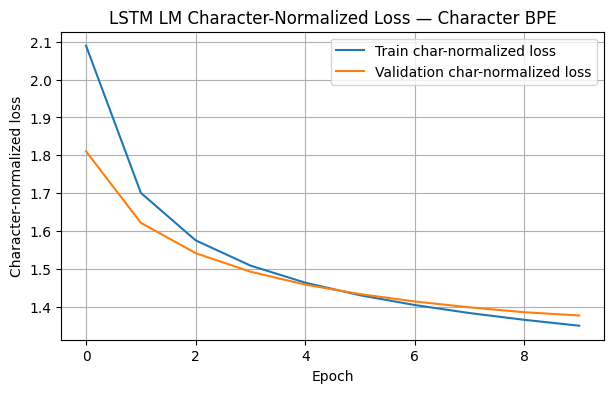

In [44]:
char_bpe_model, char_bpe_history = train_lstm_lm_with_tokenizer(
    tokenizer=bpe_tokenizer_2k,
    tokenizer_name="Character BPE",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

Epoch 01 | Train token loss: 4.4056 | Train token PPL: 81.91 | Val token loss: 3.7205 | Val token PPL: 41.29 | Val char PPL: 5.62
Epoch 02 | Train token loss: 3.5227 | Train token PPL: 33.88 | Val token loss: 3.3790 | Val token PPL: 29.34 | Val char PPL: 4.79
Epoch 03 | Train token loss: 3.2710 | Train token PPL: 26.34 | Val token loss: 3.2150 | Val token PPL: 24.90 | Val char PPL: 4.44
Epoch 04 | Train token loss: 3.1301 | Train token PPL: 22.88 | Val token loss: 3.1217 | Val token PPL: 22.68 | Val char PPL: 4.25
Epoch 05 | Train token loss: 3.0380 | Train token PPL: 20.86 | Val token loss: 3.0599 | Val token PPL: 21.33 | Val char PPL: 4.13
Epoch 06 | Train token loss: 2.9725 | Train token PPL: 19.54 | Val token loss: 3.0118 | Val token PPL: 20.32 | Val char PPL: 4.04
Epoch 07 | Train token loss: 2.9212 | Train token PPL: 18.56 | Val token loss: 2.9771 | Val token PPL: 19.63 | Val char PPL: 3.98
Epoch 08 | Train token loss: 2.8803 | Train token PPL: 17.82 | Val token loss: 2.9474 | Va

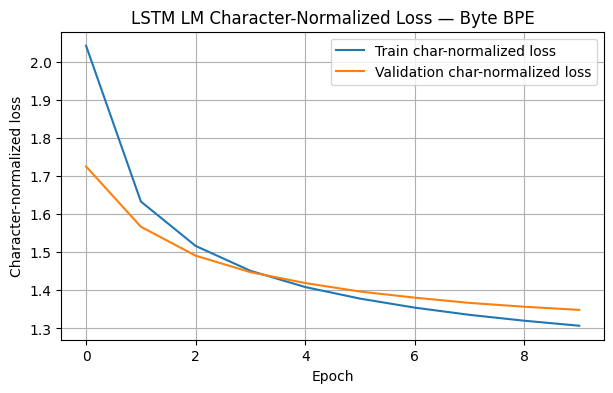

In [45]:
byte_bpe_model, byte_bpe_history = train_lstm_lm_with_tokenizer(
    tokenizer=byte_bpe_tokenizer,
    tokenizer_name="Byte BPE",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

Epoch 01 | Train token loss: 6.3726 | Train token PPL: 585.60 | Val token loss: 5.7351 | Val token PPL: 309.54 | Val char PPL: 5.86
Epoch 02 | Train token loss: 5.3215 | Train token PPL: 204.70 | Val token loss: 5.0335 | Val token PPL: 153.48 | Val char PPL: 4.72
Epoch 03 | Train token loss: 4.8251 | Train token PPL: 124.59 | Val token loss: 4.7376 | Val token PPL: 114.16 | Val char PPL: 4.31
Epoch 04 | Train token loss: 4.5867 | Train token PPL: 98.17 | Val token loss: 4.5789 | Val token PPL: 97.41 | Val char PPL: 4.10
Epoch 05 | Train token loss: 4.4443 | Train token PPL: 85.14 | Val token loss: 4.4806 | Val token PPL: 88.29 | Val char PPL: 3.98
Epoch 06 | Train token loss: 4.3444 | Train token PPL: 77.04 | Val token loss: 4.4111 | Val token PPL: 82.36 | Val char PPL: 3.90
Epoch 07 | Train token loss: 4.2670 | Train token PPL: 71.31 | Val token loss: 4.3559 | Val token PPL: 77.94 | Val char PPL: 3.83
Epoch 08 | Train token loss: 4.2041 | Train token PPL: 66.96 | Val token loss: 4.314

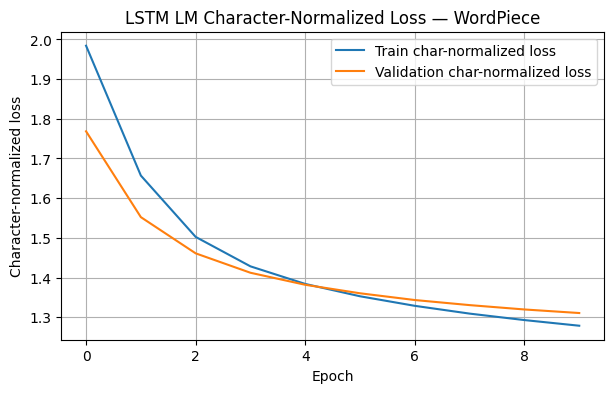

In [46]:
wordpiece_model, wordpiece_history = train_lstm_lm_with_tokenizer(
    tokenizer=wordpiece_tokenizer,
    tokenizer_name="WordPiece",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

Epoch 01 | Train token loss: 7.1771 | Train token PPL: 1309.09 | Val token loss: 6.6963 | Val token PPL: 809.41 | Val char PPL: 7.33
Epoch 02 | Train token loss: 6.2694 | Train token PPL: 528.14 | Val token loss: 5.9063 | Val token PPL: 367.35 | Val char PPL: 5.79
Epoch 03 | Train token loss: 5.7060 | Train token PPL: 300.67 | Val token loss: 5.5434 | Val token PPL: 255.53 | Val char PPL: 5.20
Epoch 04 | Train token loss: 5.4103 | Train token PPL: 223.69 | Val token loss: 5.3373 | Val token PPL: 207.95 | Val char PPL: 4.89
Epoch 05 | Train token loss: 5.2192 | Train token PPL: 184.79 | Val token loss: 5.1917 | Val token PPL: 179.78 | Val char PPL: 4.69
Epoch 06 | Train token loss: 5.0796 | Train token PPL: 160.72 | Val token loss: 5.0899 | Val token PPL: 162.37 | Val char PPL: 4.55
Epoch 07 | Train token loss: 4.9708 | Train token PPL: 144.15 | Val token loss: 5.0060 | Val token PPL: 149.31 | Val char PPL: 4.43
Epoch 08 | Train token loss: 4.8819 | Train token PPL: 131.88 | Val token l

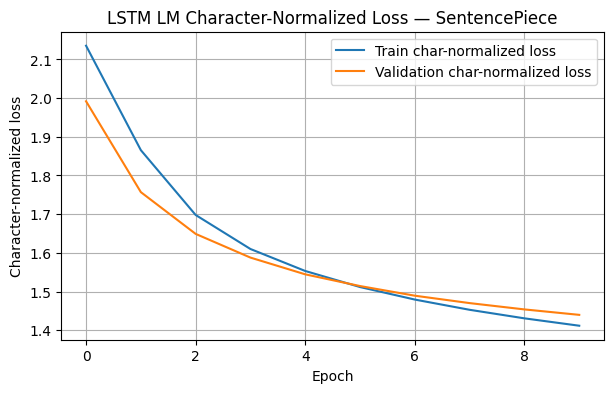

In [47]:
sp_model, sp_history = train_lstm_lm_with_tokenizer(
    tokenizer=sp_tokenizer,
    tokenizer_name="SentencePiece",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

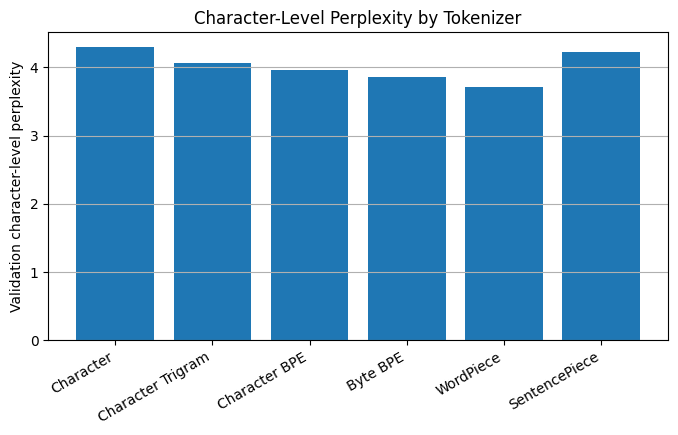

In [48]:
names = list(ppl_results.keys())
char_ppls = [ppl_results[name]["final_val_char_ppl"] for name in names]

plt.figure(figsize=(8, 4))
plt.bar(names, char_ppls)
plt.ylabel("Validation character-level perplexity")
plt.title("Character-Level Perplexity by Tokenizer")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

# Pre-trained Tokenizers

In [52]:
from transformers import AutoTokenizer

In [53]:
class HFTokenizerWrapper:
    def __init__(self, model_name):
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Some tokenizers, like GPT-2, do not have a PAD token by default.
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.pad_id = self.tokenizer.pad_token_id

        self.unk_id = (
            self.tokenizer.unk_token_id
            if self.tokenizer.unk_token_id is not None
            else self.pad_id
        )

        self.bos_id = (
            self.tokenizer.bos_token_id
            if self.tokenizer.bos_token_id is not None
            else self.tokenizer.cls_token_id
        )

        self.eos_id = (
            self.tokenizer.eos_token_id
            if self.tokenizer.eos_token_id is not None
            else self.tokenizer.sep_token_id
        )

        # Final fallback
        if self.bos_id is None:
            self.bos_id = self.eos_id

        if self.eos_id is None:
            self.eos_id = self.pad_id

    def encode(self, text, add_bos=False, add_eos=False):
        ids = self.tokenizer.encode(
            text,
            add_special_tokens=False
        )

        if add_bos:
            ids = [self.bos_id] + ids

        if add_eos:
            ids = ids + [self.eos_id]

        return ids

    def decode(self, ids):
        return self.tokenizer.decode(
            ids,
            skip_special_tokens=True
        )

    def tokenize(self, text):
        return self.tokenizer.tokenize(text)

    def vocab_size(self):
        return len(self.tokenizer)

## GPT2 (byte-level BPE)

In [54]:
gpt2_tokenizer = HFTokenizerWrapper("gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [55]:
texts = [
    "Hello world!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in texts:
    ids = gpt2_tokenizer.encode(text, add_bos=True, add_eos=True)
    decoded = gpt2_tokenizer.decode(ids)

    print("=" * 60)
    print("Text:", text)
    print("Pieces:", gpt2_tokenizer.tokenize(text))
    print("IDs:", ids)
    print("Decoded:", decoded)
    visualize_tokens(text, gpt2_tokenizer)
    print()

Text: Hello world!
Pieces: ['Hello', 'Ġworld', '!']
IDs: [50256, 15496, 995, 0, 50256]
Decoded: Hello world!



Text: café
Pieces: ['c', 'af', 'Ã©']
IDs: [50256, 66, 1878, 2634, 50256]
Decoded: café



Text: naïve
Pieces: ['na', 'Ã¯ve']
IDs: [50256, 2616, 38776, 50256]
Decoded: naïve



Text: 😊
Pieces: ['ðŁĺ', 'Ĭ']
IDs: [50256, 47249, 232, 50256]
Decoded: 😊



Text: katılamayanlardan
Pieces: ['kat', 'Ä±', 'lam', 'ayan', 'l', 'ard', 'an']
IDs: [50256, 41826, 30102, 2543, 22931, 75, 446, 272, 50256]
Decoded: katılamayanlardan



Text: 姚明进入总决赛
Pieces: ['å§', 'ļ', 'æĺ', 'İ', 'è¿', 'Ľ', 'åħ', '¥', 'æĢ', '»', 'åĨ', '³', 'è', 'µ', 'Ľ']
IDs: [50256, 34650, 248, 23626, 236, 32573, 249, 17739, 98, 45250, 119, 37863, 111, 164, 113, 249, 50256]
Decoded: 姚明进入总决赛


## BERT (WordPiece)

In [56]:
bert_tokenizer = HFTokenizerWrapper("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [57]:
texts = [
    "Hello world!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in texts:
    ids = bert_tokenizer.encode(text, add_bos=True, add_eos=True)
    decoded = bert_tokenizer.decode(ids)

    print("=" * 60)
    print("Text:", text)
    print("Pieces:", bert_tokenizer.tokenize(text))
    print("IDs:", ids)
    print("Decoded:", decoded)
    visualize_tokens(text, bert_tokenizer)
    print()

Text: Hello world!
Pieces: ['hello', 'world', '!']
IDs: [101, 7592, 2088, 999, 102]
Decoded: hello world!



Text: café
Pieces: ['cafe']
IDs: [101, 7668, 102]
Decoded: cafe



Text: naïve
Pieces: ['naive']
IDs: [101, 15743, 102]
Decoded: naive



Text: 😊
Pieces: ['[UNK]']
IDs: [101, 100, 102]
Decoded: 



Text: katılamayanlardan
Pieces: ['kat', '##ı', '##lam', '##ayan', '##lard', '##an']
IDs: [101, 10645, 11722, 10278, 25868, 20822, 2319, 102]
Decoded: katılamayanlardan



Text: 姚明进入总决赛
Pieces: ['[UNK]', '明', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '[UNK]']
IDs: [101, 100, 1865, 100, 100, 100, 100, 100, 102]
Decoded: 明


## T5 tokenizer (SentencePiece)

In [58]:
t5_tokenizer = HFTokenizerWrapper("t5-small")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [59]:
texts = [
    "Hello world!",
    "café",
    "naïve",
    "😊",
    "katılamayanlardan",
    "姚明进入总决赛",
]

for text in texts:
    ids = t5_tokenizer.encode(text, add_bos=True, add_eos=True)
    decoded = t5_tokenizer.decode(ids)

    print("=" * 60)
    print("Text:", text)
    print("Pieces:", t5_tokenizer.tokenize(text))
    print("IDs:", ids)
    print("Decoded:", decoded)
    visualize_tokens(text, t5_tokenizer)
    print()

Text: Hello world!
Pieces: ['▁Hello', '▁world', '!']
IDs: [1, 8774, 296, 55, 1]
Decoded: Hello world!



Text: café
Pieces: ['▁café']
IDs: [1, 11949, 1]
Decoded: café



Text: naïve
Pieces: ['▁', 'n', 'a', 'ï', 've']
IDs: [1, 3, 29, 9, 2, 162, 1]
Decoded: nave



Text: 😊
Pieces: ['▁', '😊']
IDs: [1, 3, 2, 1]
Decoded: 



Text: katılamayanlardan
Pieces: ['▁', 'kat', 'ı', 'la', 'may', 'an', 'l', 'ard', 'an']
IDs: [1, 3, 8682, 2, 521, 13726, 152, 40, 986, 152, 1]
Decoded: katlamayanlardan



Text: 姚明进入总决赛
Pieces: ['▁', '姚明进入总决赛']
IDs: [1, 3, 2, 1]
Decoded: 


# More Training With Pre-Trained Tokenizers

Epoch 01 | Train token loss: 7.6136 | Train token PPL: 2025.57 | Val token loss: 7.0088 | Val token PPL: 1106.31 | Val char PPL: 4.56
Epoch 02 | Train token loss: 6.7529 | Train token PPL: 856.54 | Val token loss: 6.6388 | Val token PPL: 764.18 | Val char PPL: 4.21
Epoch 03 | Train token loss: 6.4075 | Train token PPL: 606.37 | Val token loss: 6.4019 | Val token PPL: 602.99 | Val char PPL: 4.00
Epoch 04 | Train token loss: 6.1502 | Train token PPL: 468.79 | Val token loss: 6.2442 | Val token PPL: 515.04 | Val char PPL: 3.86
Epoch 05 | Train token loss: 5.9502 | Train token PPL: 383.82 | Val token loss: 6.1306 | Val token PPL: 459.73 | Val char PPL: 3.77
Epoch 06 | Train token loss: 5.7885 | Train token PPL: 326.52 | Val token loss: 6.0467 | Val token PPL: 422.70 | Val char PPL: 3.70
Epoch 07 | Train token loss: 5.6519 | Train token PPL: 284.82 | Val token loss: 5.9793 | Val token PPL: 395.17 | Val char PPL: 3.65
Epoch 08 | Train token loss: 5.5353 | Train token PPL: 253.49 | Val token 

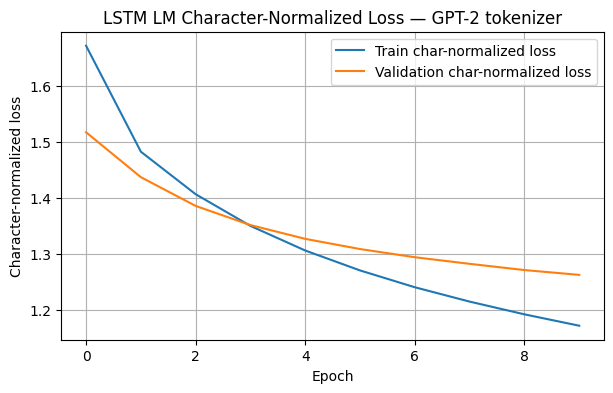

In [60]:
gpt2_model, gpt2_history = train_lstm_lm_with_tokenizer(
    tokenizer=gpt2_tokenizer,
    tokenizer_name="GPT-2 tokenizer",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

Epoch 01 | Train token loss: 7.3322 | Train token PPL: 1528.74 | Val token loss: 6.7691 | Val token PPL: 870.55 | Val char PPL: 4.11
Epoch 02 | Train token loss: 6.5551 | Train token PPL: 702.84 | Val token loss: 6.4419 | Val token PPL: 627.62 | Val char PPL: 3.84
Epoch 03 | Train token loss: 6.2526 | Train token PPL: 519.36 | Val token loss: 6.2398 | Val token PPL: 512.74 | Val char PPL: 3.68
Epoch 04 | Train token loss: 6.0373 | Train token PPL: 418.77 | Val token loss: 6.1071 | Val token PPL: 449.03 | Val char PPL: 3.58
Epoch 05 | Train token loss: 5.8726 | Train token PPL: 355.16 | Val token loss: 6.0167 | Val token PPL: 410.23 | Val char PPL: 3.52
Epoch 06 | Train token loss: 5.7372 | Train token PPL: 310.20 | Val token loss: 5.9424 | Val token PPL: 380.86 | Val char PPL: 3.46
Epoch 07 | Train token loss: 5.6219 | Train token PPL: 276.41 | Val token loss: 5.8873 | Val token PPL: 360.42 | Val char PPL: 3.42
Epoch 08 | Train token loss: 5.5217 | Train token PPL: 250.07 | Val token l

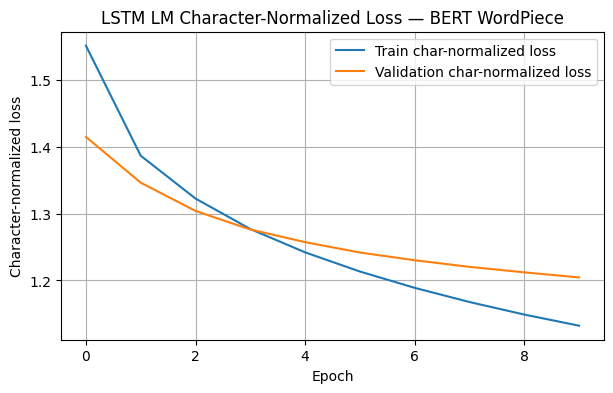

In [64]:
bert_model, bert_history = train_lstm_lm_with_tokenizer(
    tokenizer=bert_tokenizer,
    tokenizer_name="BERT WordPiece",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

Epoch 01 | Train token loss: 6.5639 | Train token PPL: 709.02 | Val token loss: 5.9879 | Val token PPL: 398.57 | Val char PPL: 4.66
Epoch 02 | Train token loss: 5.7470 | Train token PPL: 313.26 | Val token loss: 5.6296 | Val token PPL: 278.56 | Val char PPL: 4.25
Epoch 03 | Train token loss: 5.4183 | Train token PPL: 225.50 | Val token loss: 5.4031 | Val token PPL: 222.09 | Val char PPL: 4.01
Epoch 04 | Train token loss: 5.1930 | Train token PPL: 180.01 | Val token loss: 5.2542 | Val token PPL: 191.36 | Val char PPL: 3.86
Epoch 05 | Train token loss: 5.0260 | Train token PPL: 152.32 | Val token loss: 5.1490 | Val token PPL: 172.25 | Val char PPL: 3.75
Epoch 06 | Train token loss: 4.8979 | Train token PPL: 134.00 | Val token loss: 5.0723 | Val token PPL: 159.55 | Val char PPL: 3.68
Epoch 07 | Train token loss: 4.7948 | Train token PPL: 120.88 | Val token loss: 5.0109 | Val token PPL: 150.04 | Val char PPL: 3.62
Epoch 08 | Train token loss: 4.7084 | Train token PPL: 110.87 | Val token lo

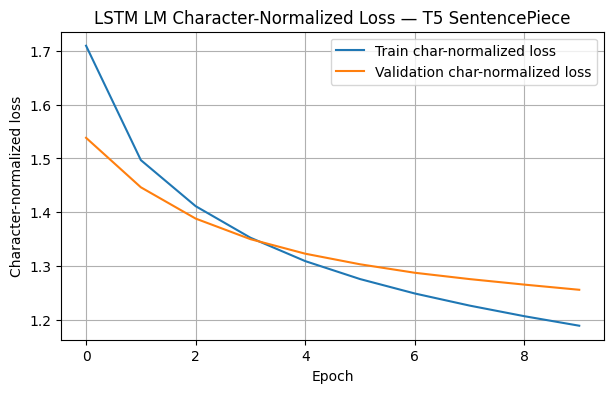

In [65]:
t5_model, t5_history = train_lstm_lm_with_tokenizer(
    tokenizer=t5_tokenizer,
    tokenizer_name="T5 SentencePiece",
    ppl_results=ppl_results,
    history_results=history_results,
    epochs=10,
)

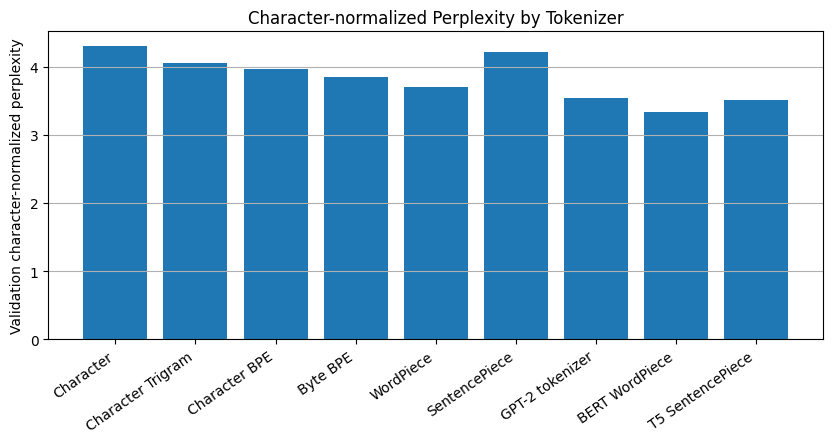

In [66]:
all_names = list(ppl_results.keys())

char_ppls = [
    ppl_results[name]["final_val_char_ppl"]
    for name in all_names
]

plt.figure(figsize=(10, 4))
plt.bar(all_names, char_ppls)
plt.ylabel("Validation character-normalized perplexity")
plt.title("Character-normalized Perplexity by Tokenizer")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.show()